# Pipeline Stage-by-Stage Debugger

A debugging notebook where **each pipeline sub-step gets its own cell** so
we can inspect each intermediate step in isolation — before moving to the next cell. This helps us understand how the method works, how different steps in the process impact the results, and diagnose and resolve any issues.

Every cell calls `inspect()`, which:
1. Runs the same three formal QA checks (`all_nan`, `out_of_range`,
   `sporadic_nan_days`) from `srm.qa_checks` — the same checks a
   `bcsd qa` run applies to a cached artifact.
2. Prints a PASS/FAIL verdict per check.
3. Plots a spatial map (`time=0`) and a domain-mean time series.
4. Registers the computed array in the `STEPS` dict so the cross-stage
   evolution plots at the bottom can iterate over every step.



In [88]:
import textwrap
import warnings

import matplotlib.pyplot as plt
import numpy as np
import rasterix  # noqa: F401  # registers .proj/.rio accessors
import xarray as xr
import xarray_regrid  # noqa: F401  # registers .regrid namespace

from srm.bcsd_config import BCSDConfig, PipelineOptions
from srm.downscaling_utils import (
    calculate_doy_means,
    downscale_from_coarse,
    get_historical_experiment,
    get_obs,
    interpolate_coarse_to_fine_grid,
    interpolate_fine_to_coarse_grid,
    subset_space,
)
from srm.pipeline import BCSDPipeline
from srm.qa_checks import _STATUS_SYMBOL, run_artifact_checks
from srm.validation import CheckStatus

warnings.filterwarnings("ignore", category=FutureWarning)


def _step_title(step: str, width: int = 16) -> str:
    """Wrap a snake_case step name to fit in a narrow subplot title."""
    return textwrap.fill(step.replace("_", " "), width=width)

## Config

**Edit only this cell** between debug runs. Set `SCENARIO = None` to debug
Stage 1 + Stage 2 only; set a scenario string to also exercise Stage 3.

`scratch_dir` and `output_dir` point to a local tmp directory so no debug
writes touch the real S3 cache.


In [89]:
# ── Edit these values ──────────────────────────────────────────────────────────
GCM = "CESM2-WACCM"
VARIABLE = "pr"
ENSEMBLE_MEMBER = "r3i1p1f1"  # CESM2-WACCM SSP245/G6-1.5K uses numeric IDs; "001" → hist r1i1p1f1
SCENARIO = None  # don't need to specify "historical" - only a future scenario

# Southern Africa including high spot in Angola.
# (lat_min, lat_max, lon_min, lon_max)
# SUBSET_BOUNDS = (-35.0, -16.0, 15.0, 39.0)
# central america for river in precip spatial disagg inspection
# SUBSET_BOUNDS = (7, 22, -100, -80)
# eastern africa for striping/hatching
SUBSET_BOUNDS = (-8, 10, 28, 43)
# ──────────────────────────────────────────────────────────────────────────────

config = BCSDConfig(
    gcm=GCM,
    variable=VARIABLE,
    ensemble_member=ENSEMBLE_MEMBER,
    scenario=SCENARIO,
    # predict_period_start must equal the scenario data start (2015 for SSP245)
    # so stitch_historical_scenario produces a gap-free 1978–end timeseries.
    predict_period_start=2015 if SCENARIO else None,
    predict_period_end=2060 if SCENARIO else None,
    subset_bounds=SUBSET_BOUNDS,
)
options = PipelineOptions(
    scratch_dir="/tmp/bcsd-debug/scratch/",  # local — never touches S3
    output_dir="/tmp/bcsd-debug/output/",
    branch="debug",
    environment="debug",
)
pipeline = BCSDPipeline(config, options)
print(f"Run: {config.run_id}")
print(f"Subset bounds: {config.subset_bounds}")
print(f"Scenario: {config.scenario!r}")
print(f"Predict period: {config.predict_period_start}–{config.predict_period_end}")

Run: CESM2-WACCM_pr_r3i1p1f1_subset
Subset bounds: (-13.0, 3.0, -90.0, -70.0)
Scenario: None
Predict period: None–None


## Inspection helper

`inspect(da, stage)` is called after every sub-step. It:
- `.compute()`s the DataArray (fine for the small subset region)
- Runs `run_artifact_checks()` (skipped for arrays with a `dayofyear` dim
  instead of a `time` dim, since those lack the time axis the checks need)
- Prints a PASS/FAIL line per check with detail for any non-PASS result
- Plots spatial map + domain-mean series
- Registers `da` in `STEPS` and its NaN fraction in `STEP_NAN_FRACTIONS`


In [3]:
STEPS: dict[str, xr.DataArray] = {}  # ordered; keys = step labels
STEP_NAN_FRACTIONS: dict[str, float] = {}  # per-step nan_fraction for bar chart


def inspect(
    da: xr.DataArray,
    stage: str,
    *,
    skip_qa: bool = False,
) -> xr.DataArray:
    """Compute, QA-check, plot, and register a pipeline intermediate."""
    print(f"\n{'=' * 60}")
    print(f"  {stage}")
    print(f"{'=' * 60}")

    da = da.compute()
    STEPS[stage] = da

    has_time = "time" in da.dims
    has_doy = "dayofyear" in da.dims

    # ── QA checks ─────────────────────────────────────────────────────────────
    if not skip_qa and has_time:
        results = run_artifact_checks(
            da,
            gcm=config.gcm,
            variable=config.variable,
            ensemble_member=config.ensemble_member,
            scenario=config.scenario,
            stage=stage,
        )
        STEP_NAN_FRACTIONS[stage] = results["all_nan"].nan_fraction
        for check_name, result in results.items():
            sym = _STATUS_SYMBOL[result.status]
            line = f"  {sym} {check_name}: {result.status.upper()}"
            if result.message:
                line += f" — {result.message}"
            print(line)
            if result.status not in (CheckStatus.PASS, CheckStatus.SKIP) and result.detail:
                for k, v in result.detail.items():
                    print(f"        {k}: {v}")
    elif has_doy:
        print("  (QA checks skipped — dayofyear dimension, no time axis)")
    else:
        print("  (QA checks skipped)")

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"  shape: {dict(da.sizes)}")
    if has_time or has_doy:
        nan_frac = float(np.isnan(da.values).mean())
        print(f"  NaN:   {nan_frac:.4f} ({nan_frac * 100:.2f}%)")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(stage, fontsize=12, fontweight="bold")
    try:
        if has_time:
            da.isel(time=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("time=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean time series")
        elif has_doy:
            da.isel(dayofyear=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("dayofyear=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean DOY series")
        else:
            for ax in axes:
                ax.text(0.5, 0.5, "no time/dayofyear dim", transform=ax.transAxes, ha="center")
    except Exception as exc:
        for ax in axes:
            ax.text(
                0.5,
                0.5,
                f"plot error:\n{exc}",
                transform=ax.transAxes,
                ha="center",
                fontsize=8,
                wrap=True,
            )
    plt.tight_layout()
    plt.show()
    return da

## ERA5-relative exceedance helpers

Adapted from `synced/notebooks/check_reasonable_ranges.ipynb`. Unlike the
global physical-bounds check in `qa_checks.py`, these compare the downscaled
output against ERA5's **per-pixel** historical min/max — so a value that is
physically plausible globally but implausible at that specific location is
still flagged.

`obs_fine_s2` / `obs_fine_s3` (already in memory) serve as the ERA5
reference, so no extra S3 reads are needed.


In [4]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    _HAS_CARTOPY = True
except ImportError:
    _HAS_CARTOPY = False

_MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Grey for zero exceedances; continuous Reds for nonzero — makes clean regions
# immediately obvious without needing a separate mask plot.
_EXCEEDANCE_CMAP = plt.cm.Reds.copy()
_EXCEEDANCE_CMAP.set_under("lightgrey")


def _era5_threshold(obs_fine: xr.DataArray, direction: str, period: str) -> xr.DataArray:
    """Per-pixel ERA5 min/max from obs_fine already in memory.

    Parameters
    ----------
    obs_fine : already-computed fine-grid ERA5 DataArray
    direction : "gt" → max threshold; "lt" → min threshold
    period    : "annual" or "monthly"
    """
    fn = "max" if direction == "gt" else "min"
    if period == "annual":
        return getattr(obs_fine, fn)("time").compute()
    return getattr(obs_fine.groupby("time.month"), fn)("time").compute()


def _count_exceedances(
    da: xr.DataArray,
    threshold: xr.DataArray,
    direction: str,
    period: str,
) -> xr.DataArray:
    """Number of time steps per pixel that exceed the given threshold."""
    if period == "annual":
        mask = da > threshold if direction == "gt" else da < threshold
        return mask.sum("time").compute()
    counts = []
    for m, group in da.groupby("time.month"):
        exceeded = (
            group > threshold.sel(month=m) if direction == "gt" else group < threshold.sel(month=m)
        )
        counts.append(exceeded.sum("time").expand_dims(month=[m]))
    return xr.concat(counts, dim="month").compute()


def _plot_map(da, ax, title, **kw):
    """Single-panel map with optional cartopy coastlines."""
    proj_kw = {"transform": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    da.plot(ax=ax, **kw, **proj_kw)
    if _HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(title, fontsize=9)


def plot_time_extremes(da: xr.DataArray, label: str) -> None:
    """2×2 grid: time-min and time-max with default and robust color scaling."""
    proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), subplot_kw=proj)
    fig.suptitle(f"{label} — time extremes", fontweight="bold")
    _plot_map(da.min("time"), axes[0, 0], "time min")
    _plot_map(da.max("time"), axes[0, 1], "time max")
    _plot_map(da.min("time"), axes[1, 0], "time min (robust)", robust=True)
    _plot_map(da.max("time"), axes[1, 1], "time max (robust)", robust=True)
    plt.tight_layout()
    plt.show()


def check_era5_exceedances(
    da: xr.DataArray,
    obs_fine: xr.DataArray,
    label: str,
    period: str = "annual",
) -> None:
    """Flag pixels where da ever exceeds ERA5's per-pixel historical min/max.

    Prints pixel counts and plots exceedance maps (grey = clean, Reds = flagged).
    Set period="monthly" for a 3×4 faceted map — slower but more granular.
    """
    print(f"\n── ERA5-relative exceedance: {label} ({period}) ──")
    n_pixels = int(da.isel(time=0).size)

    for direction, label_suffix in [("gt", "days > ERA5 max"), ("lt", "days < ERA5 min")]:
        thresh = _era5_threshold(obs_fine, direction, period)
        count = _count_exceedances(da, thresh, direction, period)

        n_flagged = int((count > 0).sum().values)
        pct = n_flagged / n_pixels
        sym = "✗" if n_flagged > 0 else "✓"
        print(f"  {sym} {label_suffix}: {n_flagged}/{n_pixels} pixels flagged ({pct:.1%})")

        proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
        if period == "annual":
            fig, ax = plt.subplots(figsize=(8, 5), subplot_kw=proj)
            _plot_map(count, ax, f"{label}\n{label_suffix}", cmap=_EXCEEDANCE_CMAP, vmin=0.5)
            plt.tight_layout()
            plt.show()
        else:
            fig, axes = plt.subplots(3, 4, figsize=(20, 10), subplot_kw=proj)
            fig.suptitle(f"{label}\n{label_suffix}", fontsize=11)
            for i, ax in enumerate(axes.flat):
                _plot_map(
                    count.sel(month=i + 1),
                    ax,
                    _MONTH_NAMES[i],
                    cmap=_EXCEEDANCE_CMAP,
                    vmin=0.5,
                )
            plt.tight_layout()
            plt.show()

## Stage 1 — `prepare_observations`

Replicates the internals of `BCSDPipeline.prepare_observations` step by step. The final cell writes the result to the debug cache so Stage 2's `_load_gcm_obs()` can find it.



  obs_fine
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 73, 'lon': 61}
  NaN:   0.0000 (0.00%)


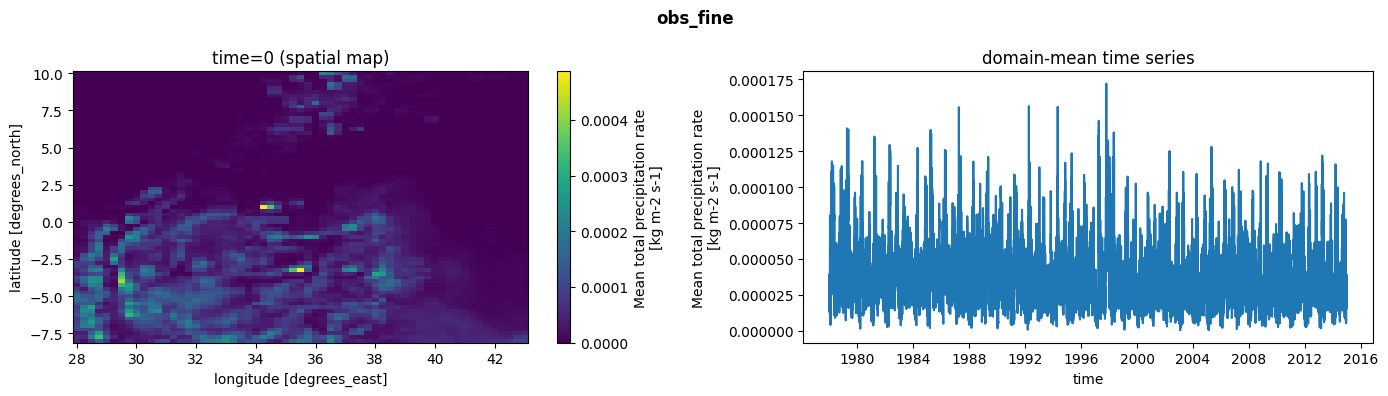

In [5]:
# ── obs_fine: fine-resolution ERA5 observations ───────────────────────────────
obs_fine = get_obs(var=config.variable, dataset_name=config.obs_dataset)
obs_fine = obs_fine.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    obs_fine = subset_space(obs_fine, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max))
train_slice = slice(str(config.train_period_start), str(config.train_period_end))
obs_fine = obs_fine.sel(time=train_slice)
obs_fine = inspect(obs_fine, "obs_fine")


  model_grid
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 19, 'lon': 12}
  NaN:   0.0000 (0.00%)


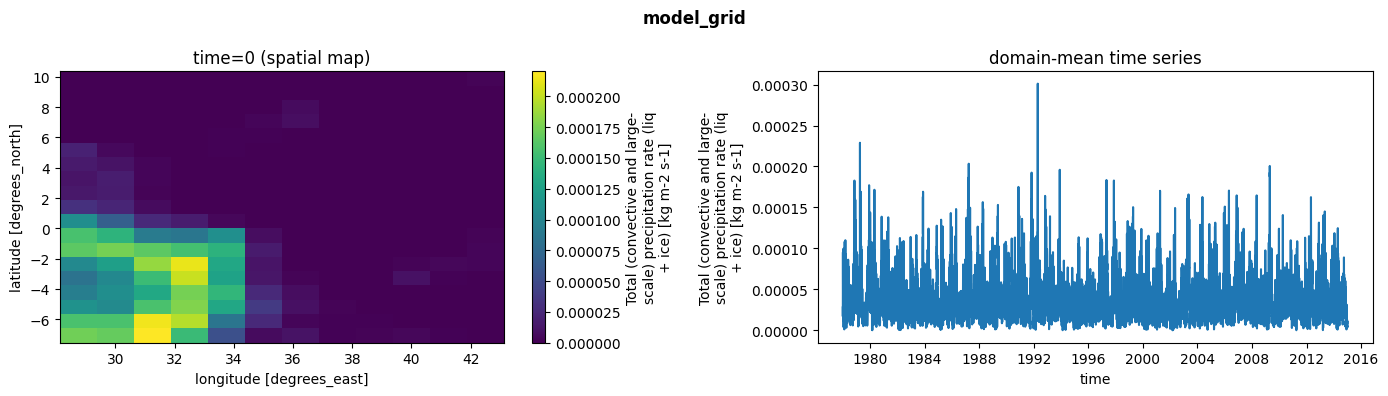

In [6]:
# ── model_grid: GCM historical run (used only as a coarse grid template) ──────
model_grid = get_historical_experiment(
    gcm=config.gcm, member=pipeline._hist_member, var=config.variable
)
model_grid = model_grid.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    model_grid = subset_space(
        model_grid, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max)
    )
model_grid = model_grid.sel(time=train_slice)
model_grid = inspect(model_grid, "model_grid")


  obs_coarse_stage1
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 19, 'lon': 12}
  NaN:   0.0000 (0.00%)


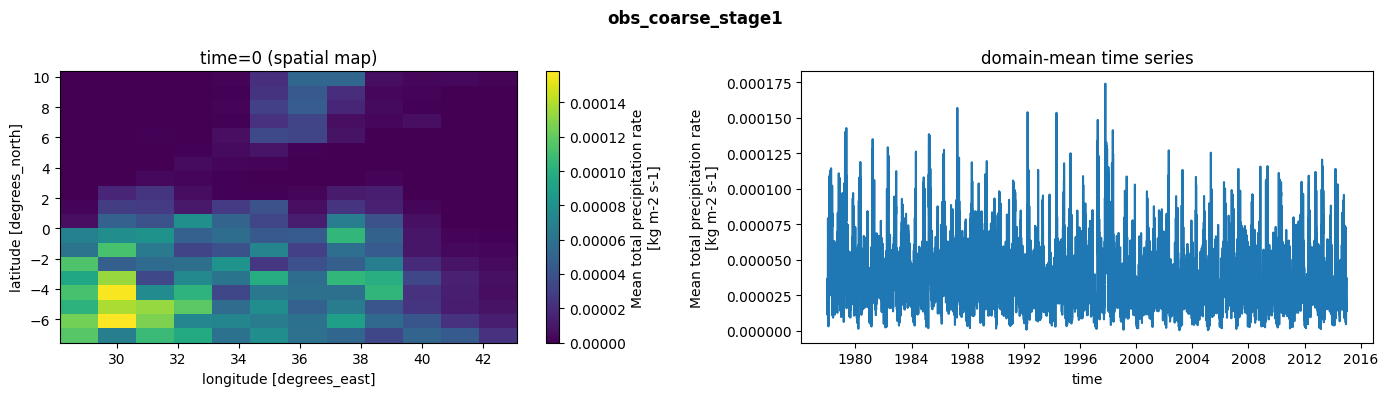

In [7]:
# ── obs_coarse: ERA5 obs regridded to the GCM coarse grid ─────────────────────
obs_coarse_stage1 = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=model_grid
)
obs_coarse_stage1 = inspect(obs_coarse_stage1, "obs_coarse_stage1")

In [8]:
%%time
# ── Write to debug cache so Stage 2 _load_gcm_obs() can find obs_regridded ───
# This is equivalent to running prepare_observations() but on the debug branch.
# force=True overwrites any previous debug-branch artifact.
print("Writing obs_coarse to debug cache via prepare_observations(force=True) ...")
prepare_obs_path = pipeline.prepare_observations(force=True)
print(f"  → {prepare_obs_path}")

Writing obs_coarse to debug cache via prepare_observations(force=True) ...
  2026-07-24T18:25:29.886540Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-07-24T18:25:30.260342Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  → /tmp/bcsd-debug/scratch/debug/CESM2-WACCM-ERA5-lat-8.0to10.0_lon28.0to43.0.icechunk
CPU times: user 3min 16s, sys: 56 s, total: 4min 12s
Wall time: 29.6 s


## Stage 2 — `fit_historical` (debiasing + spatial downscaling)


  2026-07-24T18:25:59.444451Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-07-24T18:25:59.445396Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196


  obs_coarse
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 19, 'lon': 12}
  NaN:   0.0000 (0.00%)


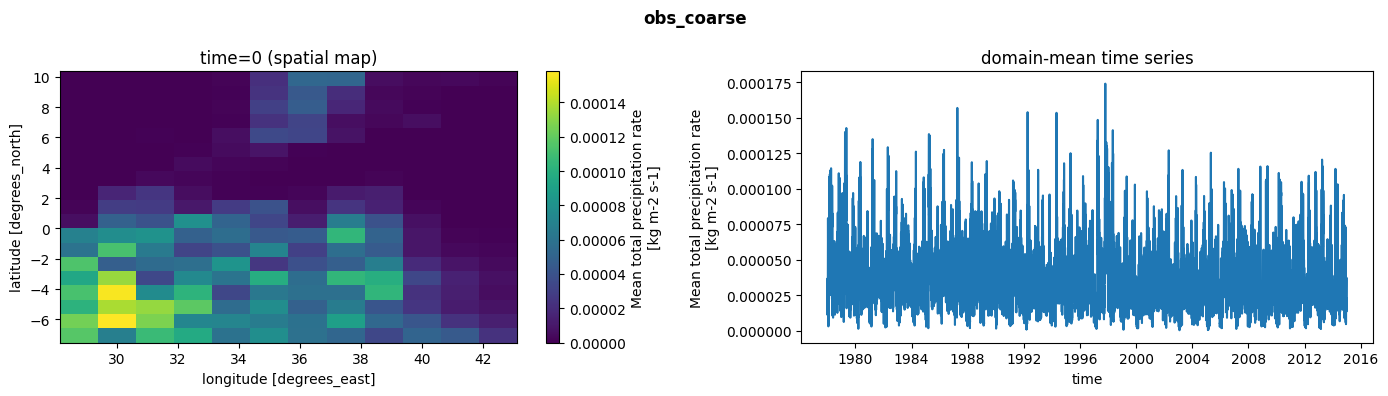


  obs_fine_s2
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 73, 'lon': 61}
  NaN:   0.0000 (0.00%)


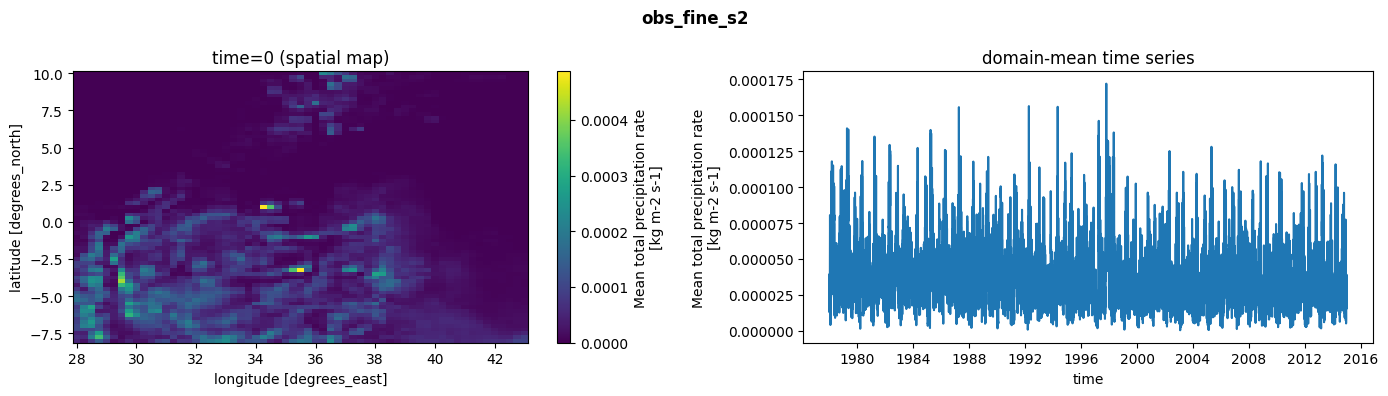


  model_hist
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 19, 'lon': 12}
  NaN:   0.0000 (0.00%)


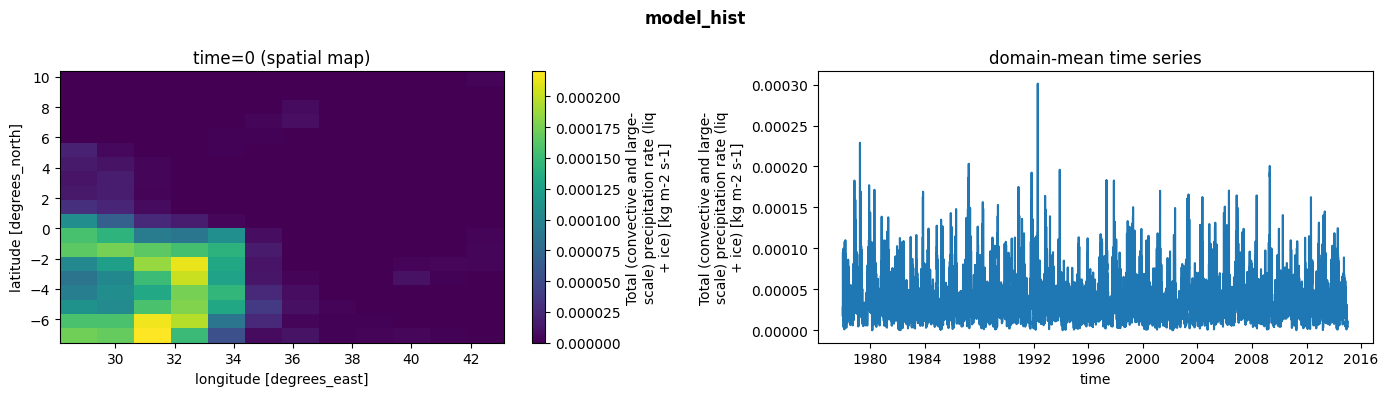

CPU times: user 1min 50s, sys: 28.6 s, total: 2min 19s
Wall time: 14.9 s


In [9]:
%%time
# ── _load_gcm_obs: reload from debug cache + load obs_fine, model_hist ────────
obs_coarse, obs_fine_s2, model_hist = pipeline._load_gcm_obs()
obs_coarse = inspect(obs_coarse, "obs_coarse")
obs_fine_s2 = inspect(obs_fine_s2, "obs_fine_s2")
model_hist = inspect(model_hist, "model_hist")


  debiased_coarse
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 19, 'lon': 12}
  NaN:   0.0000 (0.00%)


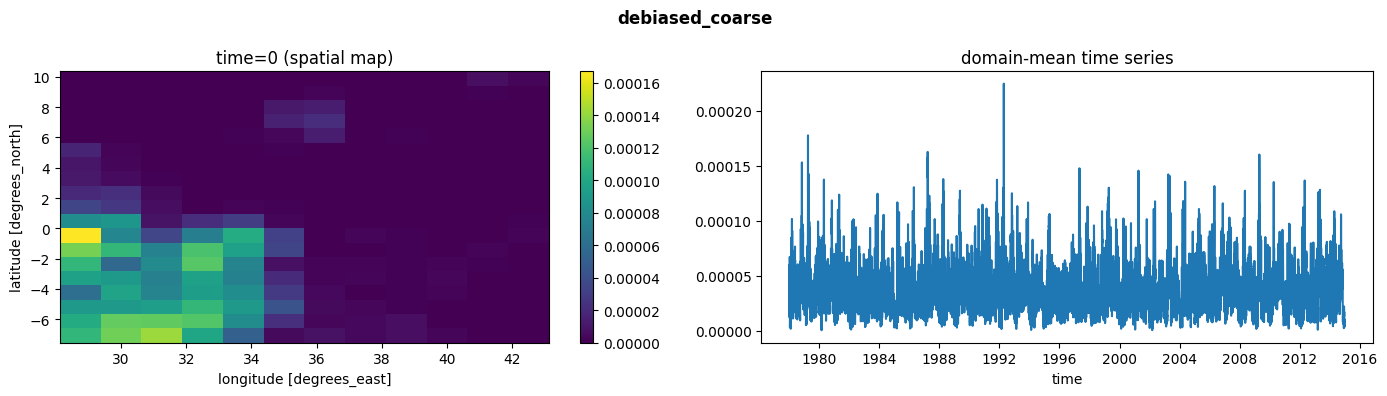

CPU times: user 273 ms, sys: 8.31 s, total: 8.58 s
Wall time: 9.41 s


In [10]:
%%time
# ── _apply_bias_correction: ibicus QuantileMapping on historical period ────────
# It calls .values / .load() internally so it is always eager; runtime ~ 1–5 min
# on the South Africa subset.
debiased_coarse = pipeline._apply_bias_correction(obs_coarse, model_hist)
debiased_coarse = inspect(debiased_coarse, "debiased_coarse")

### Spatial disaggregation sub-steps (Stage 2)

The single `_apply_spatial_downscaling()` call is expanded into five named
intermediates (Cells A–E) plus a consistency check (Cell F), so each step
can be inspected independently. These mirror the internals of
`downscale_from_coarse()` exactly.

> **Cell A** and **Cell B** compute the obs climatology, which is
> scenario-independent. The arrays will be reused in Stage 3 (starting from
> Cell C) so those cells do not need to rerun them.



  obs_fine_doy_means
  (QA checks skipped — dayofyear dimension, no time axis)
  shape: {'dayofyear': 366, 'lat': 73, 'lon': 61}
  NaN:   0.0000 (0.00%)


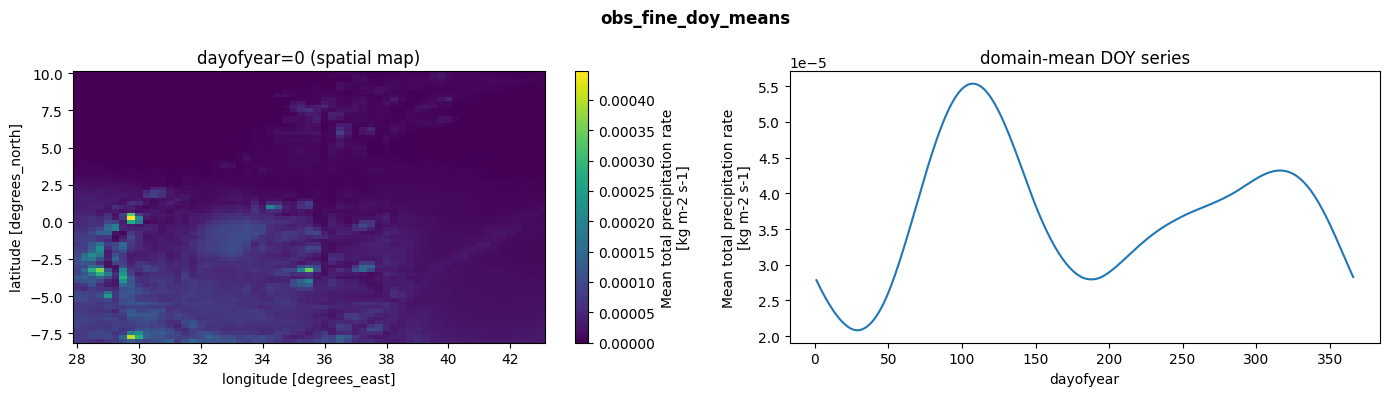

CPU times: user 716 ms, sys: 14.2 ms, total: 730 ms
Wall time: 546 ms


In [11]:
%%time
# ── Cell A: fine-grid day-of-year climatology ──────────────────────────────────
# Uses the downscaling_clim_method from config (typically "fft" for most vars).
obs_fine_doy_means = calculate_doy_means(
    obs_fine_s2,
    clim_method=config.variable_config.downscaling_clim_method,
    allow_negative_values=False,
)
obs_fine_doy_means = inspect(obs_fine_doy_means, "obs_fine_doy_means")

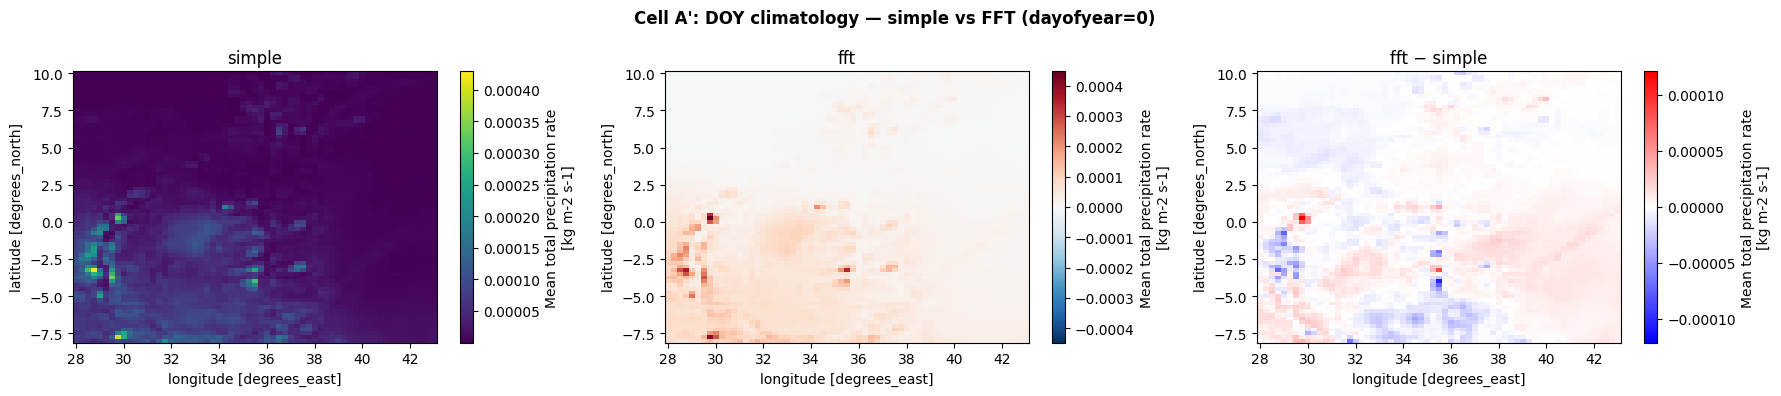

CPU times: user 728 ms, sys: 2.52 ms, total: 731 ms
Wall time: 424 ms


In [12]:
%%time
# ── Cell A': FFT vs simple climatology comparison ─────────────────────────────
# Three-panel map: simple | fft | diff (bwr, center=0) for dayofyear=0.
# Reveals FFT-smoothing artifacts found in prior QA notebooks.
obs_fine_doy_means_simple = calculate_doy_means(obs_fine_s2, clim_method="simple")
obs_fine_doy_means_fft = calculate_doy_means(obs_fine_s2, clim_method="fft")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Cell A': DOY climatology — simple vs FFT (dayofyear=0)", fontweight="bold")
kw = dict(add_colorbar=True)
obs_fine_doy_means_simple.isel(dayofyear=0).plot(ax=axes[0], **kw)
axes[0].set_title("simple")
obs_fine_doy_means_fft.isel(dayofyear=0).plot(ax=axes[1], **kw)
axes[1].set_title("fft")
diff = (obs_fine_doy_means_fft - obs_fine_doy_means_simple).isel(dayofyear=0)
diff.plot(ax=axes[2], cmap="bwr", center=0, **kw)
axes[2].set_title("fft − simple")
plt.tight_layout()
plt.show()


  obs_coarse_doy_means
  (QA checks skipped — dayofyear dimension, no time axis)
  shape: {'dayofyear': 366, 'lat': 19, 'lon': 12}
  NaN:   0.0000 (0.00%)


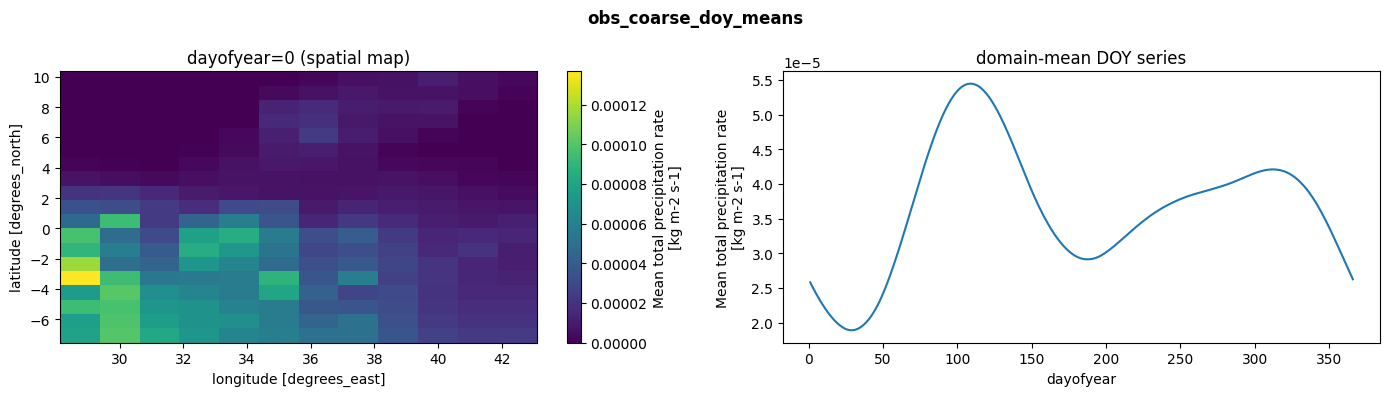

In [13]:
# ── Cell B: coarsen DOY climatology to GCM grid ───────────────────────────────
obs_coarse_doy_means = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine_doy_means, da_coarse_grid=obs_coarse
)
obs_coarse_doy_means = inspect(obs_coarse_doy_means, "obs_coarse_doy_means")

In [14]:
#


  residuals_coarse
  ✓ all_nan: PASS
  ✗ out_of_range: FAIL — 78.92% of values outside [0, 0.03]
        out_of_range_fraction: 0.7892163162827892
        actual_min: 0.0
        actual_max: 100.0
        expected_min: 0
        expected_max: 0.03
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 19, 'lon': 12}
  NaN:   0.0000 (0.00%)


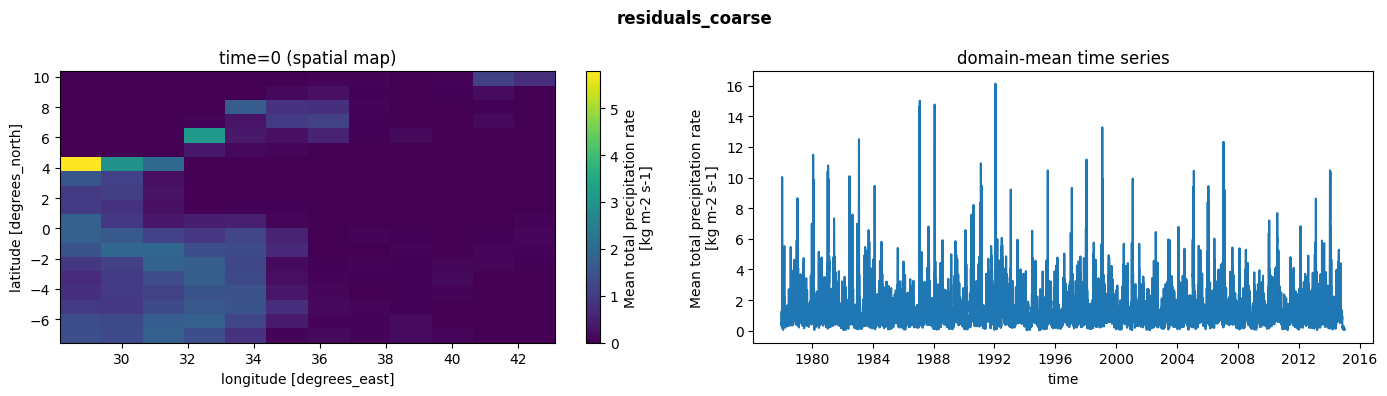

In [15]:
# ── Cell C: coarse spatial residuals (debiased − coarse climatology) ──────────
if config.variable_config.downscaling_method == "additive":
    residuals_coarse = debiased_coarse.groupby("time.dayofyear") - obs_coarse_doy_means
elif config.variable_config.downscaling_method == "multiplicative":
    max_residual = 100
    # Guard the denominator: where coarse climatology is zero (dry cells/days),
    # the NCL reference forces the ratio to 0 rather than producing inf/NaN.
    # Replace exact zeros with NaN so the division yields NaN, then fill those
    # specific locations with 0 after dividing.
    zero_clim = obs_coarse_doy_means == 0
    safe_clim = obs_coarse_doy_means.where(~zero_clim)  # zeros -> NaN

    residuals_coarse = debiased_coarse.groupby("time.dayofyear") / safe_clim

    # Force ratio to 0 exactly where the coarse climatology was zero.
    # Broadcast the per-DOY zero mask back onto the time axis.
    zero_clim_on_time = zero_clim.sel(dayofyear=debiased_coarse["time"].dt.dayofyear)
    residuals_coarse = residuals_coarse.where(~zero_clim_on_time, 0.0).clip(max=max_residual)
residuals_coarse = inspect(residuals_coarse, "residuals_coarse")


  residuals_fine
  ✓ all_nan: PASS
  ✗ out_of_range: FAIL — 83.75% of values outside [0, 0.03]
        out_of_range_fraction: 0.8375371385789775
        actual_min: 0.0
        actual_max: 100.0
        expected_min: 0
        expected_max: 0.03
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 73, 'lon': 61}
  NaN:   0.1448 (14.48%)


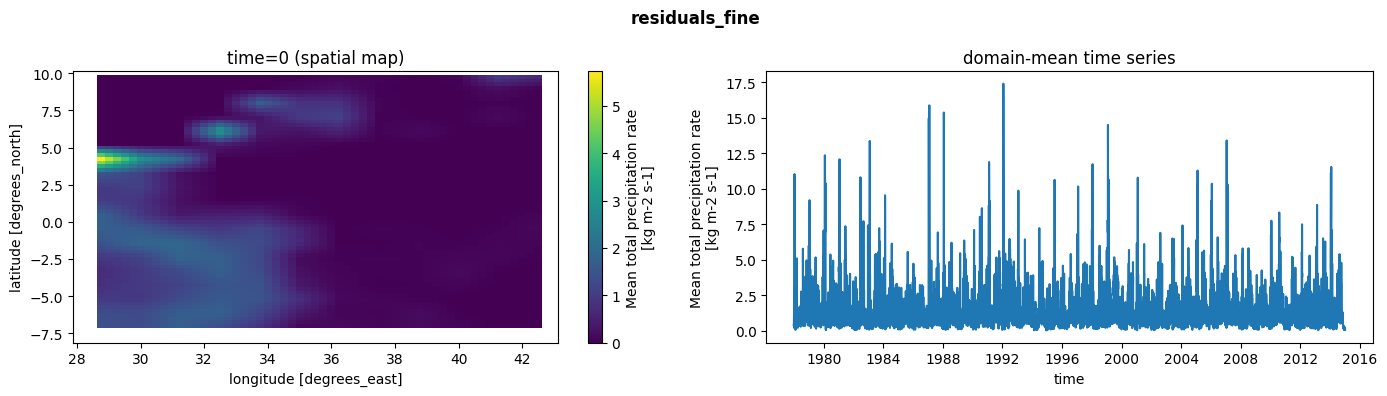

In [16]:
# ── Cell D: interpolate residuals to fine grid ────────────────────────────────
residuals_fine = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=residuals_coarse, da_fine_grid=obs_fine_s2
)
residuals_fine = inspect(residuals_fine, "residuals_fine")


  downscaled
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 73, 'lon': 61}
  NaN:   0.1448 (14.48%)


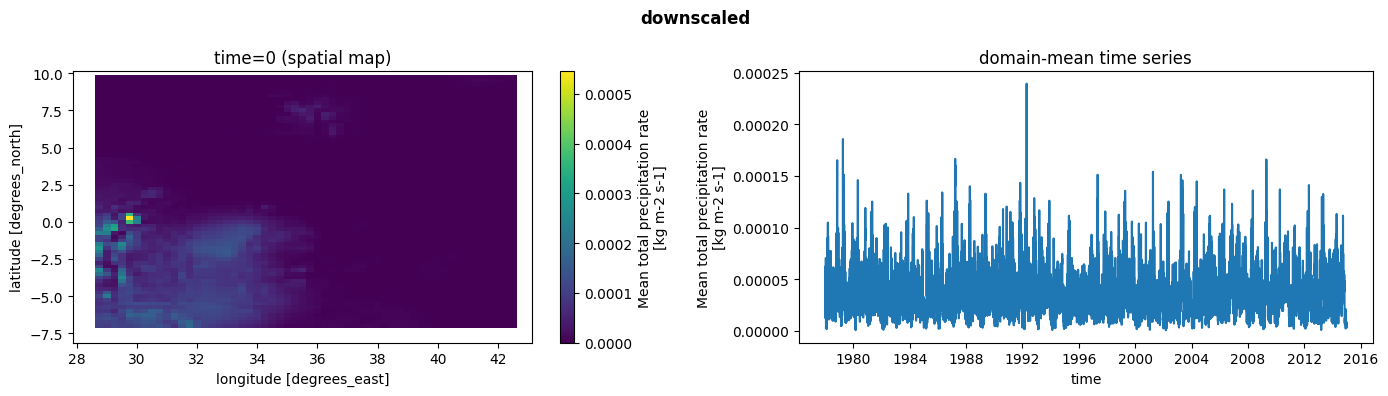

In [17]:
# ── Cell E: reapply fine-grid DOY climatology → final downscaled field ─────────
if config.variable_config.downscaling_method == "additive":
    downscaled = residuals_fine.groupby("time.dayofyear") + obs_fine_doy_means
elif config.variable_config.downscaling_method == "multiplicative":
    downscaled = residuals_fine.groupby("time.dayofyear") * obs_fine_doy_means
downscaled = inspect(downscaled, "downscaled")

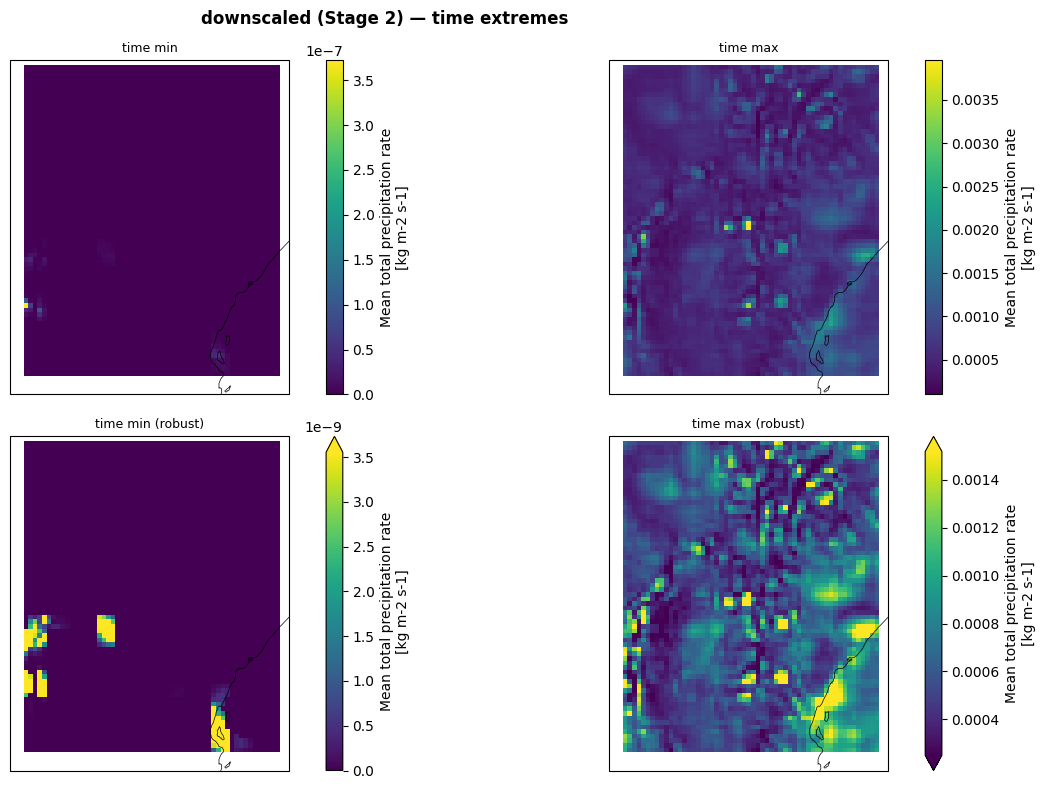


── ERA5-relative exceedance: downscaled (Stage 2) (annual) ──
  ✗ days > ERA5 max: 225/4453 pixels flagged (5.1%)


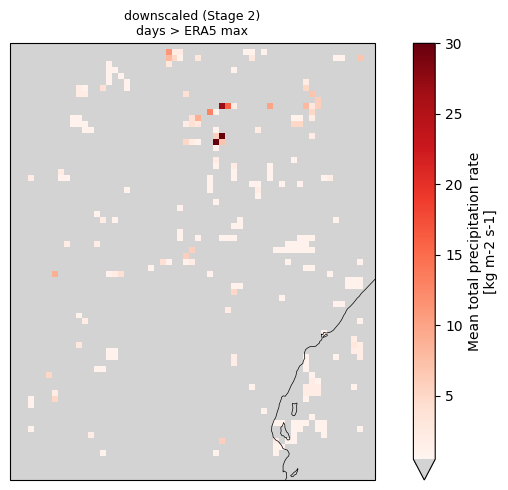

  ✓ days < ERA5 min: 0/4453 pixels flagged (0.0%)


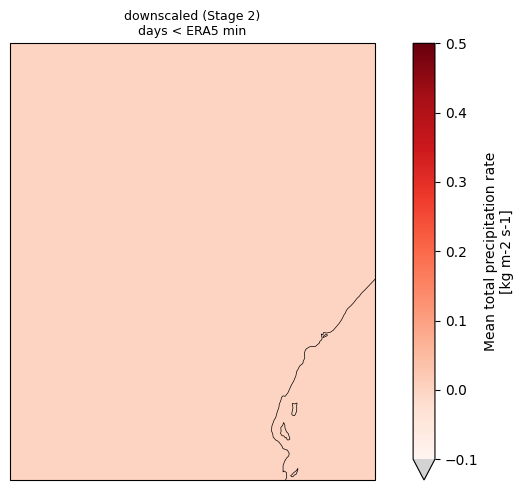

In [18]:
# ── ERA5 exceedance check: downscaled (Stage 2) ───────────────────────────────
# plot_time_extremes: 2×2 grid catches both sign errors (negative pr)
# and extreme outliers that a mean or single-timestep map would hide.
plot_time_extremes(downscaled, "downscaled (Stage 2)")

# Annual check first (fast); switch to period="monthly" to localise
# seasonally-specific exceedances (e.g. summer precipitation extremes).
check_era5_exceedances(downscaled, obs_fine_s2, "downscaled (Stage 2)")
# check_era5_exceedances(downscaled, obs_fine_s2, "downscaled (Stage 2)", period="monthly")

In [41]:
bias_coarse = debiased_coarse.mean(dim="time") - obs_coarse.mean(dim="time")
pbias_coarse = bias_coarse / obs_coarse.mean(dim="time") * 100

Text(0.5, 1.0, 'Mean daily bias')

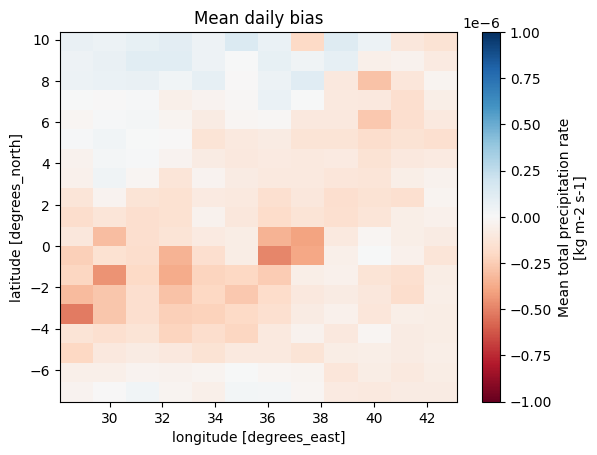

In [46]:
(bias_coarse).plot(vmin=-1e-6, vmax=1e-6, cmap="RdBu")
plt.title("Mean daily bias")

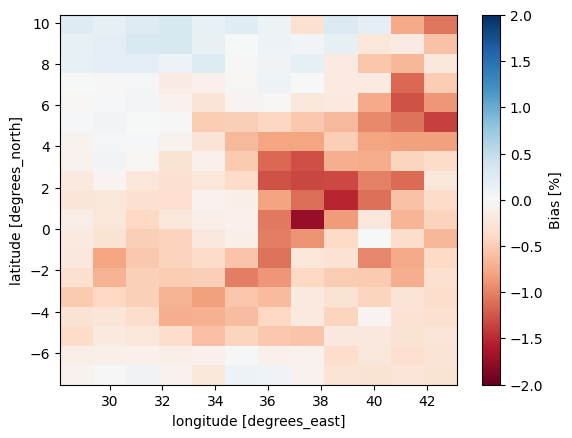

In [51]:
(pbias_coarse).plot(vmin=-2, vmax=2, cmap="RdBu", cbar_kwargs={"label": "Bias [%]"})

In the coarse bias-corrected this region is almost exclusively high biased (and only slightly ~1%). But upon adding in the spatial disaggregation the bias becomes ~-5 to upwards of 10% in some places. What's going on there?

In [37]:
bias = downscaled.mean(dim="time") - obs_fine.mean(dim="time")
pbias = bias / obs_fine.mean(dim="time") * 100

Text(0.5, 1.0, 'Mean daily bias')

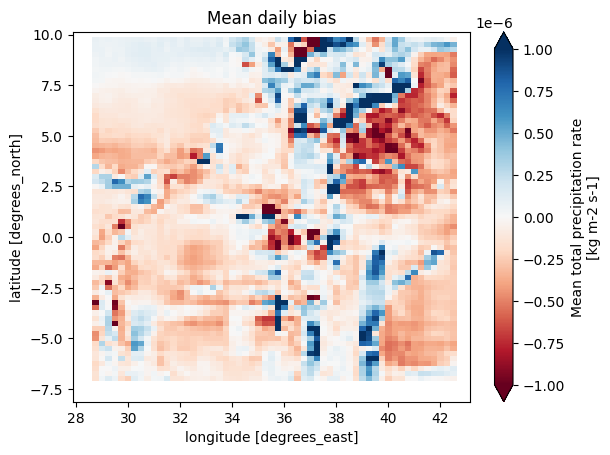

In [48]:
(bias).plot(vmin=-1e-6, vmax=1e-6, cmap="RdBu")
plt.title("Mean daily bias")

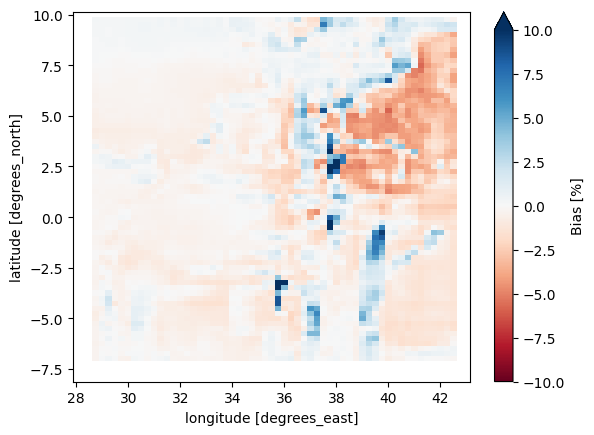

In [47]:
(pbias).plot(vmin=-10, vmax=10, cmap="RdBu", cbar_kwargs={"label": "Bias [%]"})

In [72]:
pixels = {"high_bias": (2.5, 37.75), "low_bias": (2.5, 37.5)}

Pick an individual pixel - the one that ends up having a 15% bias at (2.5, 38).

In [73]:
situation = "high_bias"
pbias.sel(lat=pixels[situation][0], lon=pixels[situation][1]).values

array(14.472684, dtype=float32)

Then let's pick a pixel right next door that has very little bias post disaggregation.

In [74]:
situation = "low_bias"
pbias.sel(lat=pixels[situation][0], lon=pixels[situation][1]).values

array(-1.9363573, dtype=float32)

-7.4909156e-07
-6.980215e-07


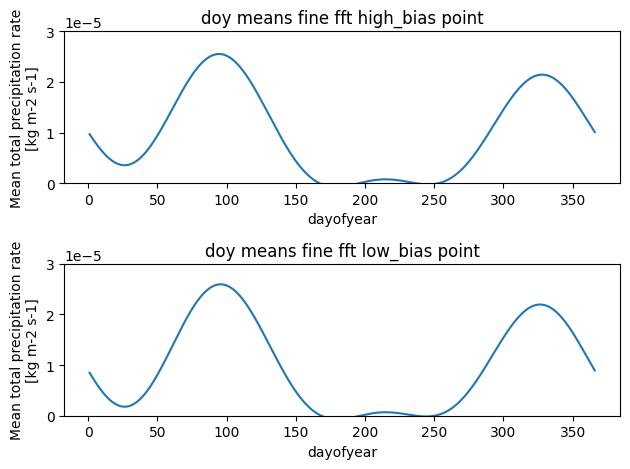

In [86]:
fig, axarr = plt.subplots(2)
for i, (situation, (lat, lon)) in enumerate(pixels.items()):
    obs_fine_doy_means_fft.sel(lat=lat, lon=lon).plot(ax=axarr[i])
    axarr[i].set_ylim(0, 3e-5)
    axarr[i].set_title(f"doy means fine fft {situation} point")
    print(obs_fine_doy_means_fft.sel(lat=lat, lon=lon).min().values)
plt.tight_layout()

In [ ]:
obs_fine_doy_means_fft

In [79]:
diff = obs_fine_doy_means_fft.sel(
    lat=pixels["high_bias"][0], lon=pixels["high_bias"][1]
) - obs_fine_doy_means_fft.sel(lat=pixels["low_bias"][0], lon=pixels["low_bias"][1])

Text(0.5, 1.0, 'difference in doy means between the two set-ups')

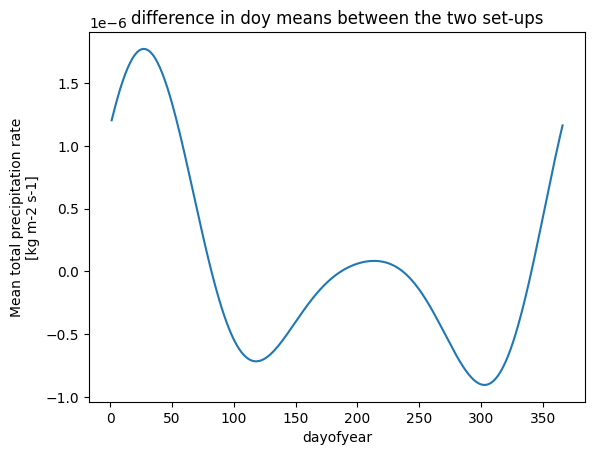

In [81]:
diff.plot()
plt.title("difference in doy means between the two set-ups")

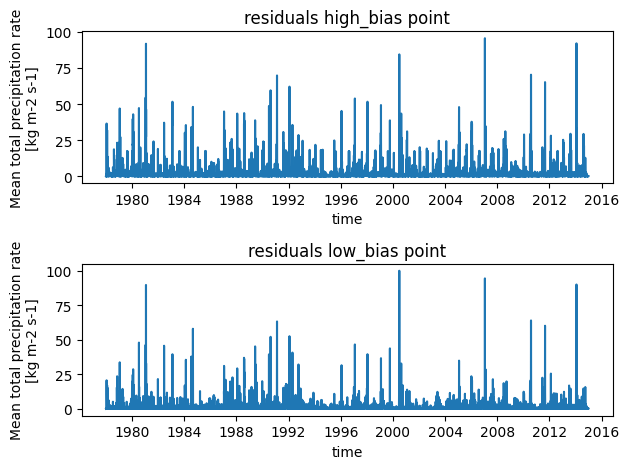

In [76]:
fig, axarr = plt.subplots(2)
for i, (situation, (lat, lon)) in enumerate(pixels.items()):
    residuals_fine.sel(lat=lat, lon=lon).plot(ax=axarr[i])
    axarr[i].set_title(f"residuals {situation} point")
plt.tight_layout()

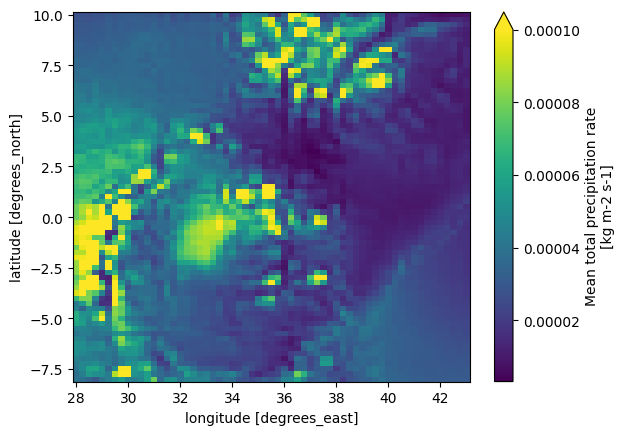

In [31]:
obs_fine.mean(dim="time").plot(vmax=0.0001)

In [25]:
xr.testing.assert_equal(obs_fine_s2, obs_fine)

In [20]:
%%time
# ── Cell F: consistency check vs production downscale_from_coarse() ───────────
# Fails loudly if step-by-step result diverges from the production function.
ref = downscale_from_coarse(
    da=debiased_coarse,
    obs_coarse=obs_coarse,
    obs_fine=obs_fine_s2,
    method=config.variable_config.downscaling_method,
    clim_method=config.variable_config.downscaling_clim_method,
    allow_negative_values=False,
).compute()

match = np.allclose(downscaled.values, ref.values, equal_nan=True)
print(f"Consistency check (Cell F): {'PASS ✓' if match else 'FAIL ✗'}")
assert match, (
    "Step-by-step result diverges from downscale_from_coarse(). "
    "Check residual formulation or interpolation order."
)

Consistency check (Cell F): PASS ✓
CPU times: user 699 ms, sys: 45.2 ms, total: 745 ms
Wall time: 583 ms


In [87]:
%%time
# ── Cell F: consistency check vs production downscale_from_coarse() ───────────
# Fails loudly if step-by-step result diverges from the production function.
ref = downscale_from_coarse(
    da=debiased_coarse,
    obs_coarse=obs_coarse,
    obs_fine=obs_fine_s2,
    method=config.variable_config.downscaling_method,
    clim_method=config.variable_config.downscaling_clim_method,
    allow_negative_values=False,
).compute()

match = np.allclose(downscaled.values, ref.values, equal_nan=True)
print(f"Consistency check (Cell F): {'PASS ✓' if match else 'FAIL ✗'}")
assert match, (
    "Step-by-step result diverges from downscale_from_coarse(). "
    "Check residual formulation or interpolation order."
)

Consistency check (Cell F): PASS ✓
CPU times: user 663 ms, sys: 94.9 ms, total: 758 ms
Wall time: 590 ms


In [19]:
# ── Optional: write historical to debug cache for Stage 3 ─────────────────────
# Only needed if you plan to run Stage 3 cells below.  Uncomment and run.
# print("Writing fit_historical to debug cache ...")
# hist_path = pipeline.fit_historical(force=True)
# print(f"  → {hist_path}")
